In [1]:
"""
PCEC96          # Real Personal Consumption Expenditures (for target generation)
FEDFUNDS        # Federal Funds Effective Rate (Policy Rate)
CPIAUCSL        # Consumer Price Index (Headline CPI)
CPILFESL        # Core Consumer Price Index
UNRATE          # Unemployment Rate
DSPIC96         # Real Disposable Personal Income

Unused:
DTB3            # 3-Month Treasury Bill Rate (Short-term Rate)
DGS10           # 10-Year Treasury Constant Maturity Rate (Long-term Rate)
PAYEMS          # Nonfarm Payrolls (Employment)
UMCSENT         # University of Michigan: Consumer Sentiment

DATE
PCEC96          # 소비 (target 생성용)
FEDFUNDS        # 기준금리
DTB3            # 단기금리
DGS10           # 장기금리
CPIAUCSL        # CPI
CPILFESL        # Core CPI
UNRATE          # 실업률
PAYEMS          # 고용
DSPIC96         # 실질 가처분소득
UMCSENT         # (선택)
"""

'\nPCEC96          # Real Personal Consumption Expenditures (for target generation)\nFEDFUNDS        # Federal Funds Effective Rate (Policy Rate)\nCPIAUCSL        # Consumer Price Index (Headline CPI)\nCPILFESL        # Core Consumer Price Index\nUNRATE          # Unemployment Rate\nDSPIC96         # Real Disposable Personal Income\n\nUnused:\nDTB3            # 3-Month Treasury Bill Rate (Short-term Rate)\nDGS10           # 10-Year Treasury Constant Maturity Rate (Long-term Rate)\nPAYEMS          # Nonfarm Payrolls (Employment)\nUMCSENT         # University of Michigan: Consumer Sentiment\n\nDATE\nPCEC96          # 소비 (target 생성용)\nFEDFUNDS        # 기준금리\nDTB3            # 단기금리\nDGS10           # 장기금리\nCPIAUCSL        # CPI\nCPILFESL        # Core CPI\nUNRATE          # 실업률\nPAYEMS          # 고용\nDSPIC96         # 실질 가처분소득\nUMCSENT         # (선택)\n'

In [2]:
import pandas as pd
from sklearn.linear_model import Ridge
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
import missingno as msno
import glob
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
def load_series(path, col_name):
    df = pd.read_csv(path) 
    df.columns = ["DATE", col_name]
    df["DATE"] = pd.to_datetime(df["DATE"])
    return df

In [4]:
pce       = load_series("./data/PCEC96.csv", "PCEC96")
fedfunds = load_series("./data/FEDFUNDS.csv", "FEDFUNDS")
cpi       = load_series("./data/CPIAUCSL.csv", "CPI")
core_cpi = load_series("./data/CPILFESL.csv", "CORE_CPI")
unrate   = load_series("./data/UNRATE.csv", "UNRATE")
payems   = load_series("./data/PAYEMS.csv", "PAYEMS")
income   = load_series("./data/DSPIC96.csv", "DSPIC96")
dtb3  = load_series("./data/DTB3.csv", "DTB3")
dgs10 = load_series("./data/DGS10.csv", "DGS10")

In [5]:
# Calculate yield spread
# Optional feature
"""
try:
    rates = pd.merge(dgs10, dtb3, on="DATE", how="inner")
    rates["YIELD_SPREAD"] = rates["DGS10"] - rates["DTB3"]
except:
    rates = None
"""

'\ntry:\n    rates = pd.merge(dgs10, dtb3, on="DATE", how="inner")\n    rates["YIELD_SPREAD"] = rates["DGS10"] - rates["DTB3"]\nexcept:\n    rates = None\n'

In [6]:
dfs = [pce, fedfunds, cpi, core_cpi, unrate, payems, income]

df = dfs[0]
for d in dfs[1:]:
    df = pd.merge(df, d, on="DATE", how="left")

# if rates is not None:
#     df = pd.merge(df, rates[["DATE", "YIELD_SPREAD"]], on="DATE", how="left")

df = df.sort_values("DATE").reset_index(drop=True)

In [7]:
"""
Natural log is commonly used in measuring rate of change economics and finance.
While percentage changes must be multiplied to combine multiple periods, 
log changes only need to be summed, which makes multi-period analysis much simpler.
For small changes, log changes are very close to percentage changes, so they provide a convenient and reliable way to measure growth rates.
"""

df["log_PCE"] = np.log(df["PCEC96"])

# COVID-19 period indicator
df["COVID"] = ((df["DATE"] >= "2020-03-01") & (df["DATE"] <= "2021-06-01")).astype(int)

# change of log_PCE, create target y
df["3m_PCE_change"] = df["log_PCE"].shift(-3) - df["log_PCE"]

# df["FEDFUNDS_d1"] = df["FEDFUNDS"].diff(1)
# df["UNRATE_d1"]   = df["UNRATE"].diff(1) 
df["CPI_d1"]      = np.log(df["CPI"]).diff(1)    
df["CORE_CPI_d1"] = np.log(df["CORE_CPI"]).diff(1)
df["DSPIC96_d1"]  = np.log(df["DSPIC96"]).diff(1)

In [8]:
lag_cols = ["FEDFUNDS", "UNRATE"]
lag_d1_cols = ["CPI_d1", "CORE_CPI_d1", "DSPIC96_d1"]

# 1m, 3m lag features
for col in lag_cols:
    df[f"{col}_lag1"] = df[col].shift(1)
    #df[f"{col}_lag3"] = df[col].shift(3)

for col in lag_d1_cols:
    df[f"{col}_lag1"] = df[col].shift(1)
    #df[f"{col}_lag3"] = df[col].shift(3)

# if "YIELD_SPREAD" in df.columns:
#     df["YIELD_SPREAD_lag1"] = df["YIELD_SPREAD"].shift(1)

In [9]:
# automatically include all lag features
features = [c for c in df.columns if c.endswith("_lag1") or c.endswith("_lag3")]
features.append("COVID")
features = sorted(features)  

model_df = df[["DATE", "3m_PCE_change"] + features].dropna().reset_index(drop=True)
print("Num features:", len(features))
print(model_df.head())

Num features: 6
        DATE  3m_PCE_change  CORE_CPI_d1_lag1  COVID  CPI_d1_lag1  \
0 2007-03-01       0.002481          0.002561      0     0.003871   
1 2007-04-01       0.004552          0.001352      0     0.005187   
2 2007-05-01       0.007292          0.001570      0     0.002996   
3 2007-06-01       0.008088          0.001482      0     0.004124   
4 2007-07-01       0.005848          0.001589      0     0.002314   

   DSPIC96_d1_lag1  FEDFUNDS_lag1  UNRATE_lag1  
0         0.003290           5.26          4.5  
1         0.003254           5.26          4.4  
2         0.001470           5.25          4.5  
3         0.000589           5.25          4.4  
4        -0.000547           5.25          4.6  


In [10]:
print(model_df.tail())
print(model_df.info())

          DATE  3m_PCE_change  CORE_CPI_d1_lag1  COVID  CPI_d1_lag1  \
215 2025-02-01       0.007757          0.004453      0     0.004658   
216 2025-03-01       0.002578          0.002264      0     0.002157   
217 2025-04-01       0.006285          0.000565      0    -0.000500   
218 2025-05-01       0.010629          0.002365      0     0.002206   
219 2025-06-01       0.009134          0.001298      0     0.000808   

     DSPIC96_d1_lag1  FEDFUNDS_lag1  UNRATE_lag1  
215         0.001225           4.33          4.0  
216         0.001156           4.33          4.2  
217         0.006600           4.33          4.2  
218         0.005741           4.33          4.2  
219        -0.008418           4.33          4.3  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   DATE              220 non-null    datetime64[ns]
 

In [11]:
SPLIT_DATE = pd.Timestamp("2020-01-01")

train_df = model_df[model_df["DATE"] < SPLIT_DATE].copy() 
test_df  = model_df[model_df["DATE"] >= SPLIT_DATE].copy()

X_train = train_df[features]                               
y_train = train_df["3m_PCE_change"]                         

X_test  = test_df[features]                                 
y_test  = test_df["3m_PCE_change"]                           

print("Train rows:", len(train_df), "Test rows:", len(test_df))
print("Train date range:", train_df["DATE"].min(), "to", train_df["DATE"].max())
print("Test date range:",  test_df["DATE"].min(),  "to", test_df["DATE"].max()) 


Train rows: 154 Test rows: 66
Train date range: 2007-03-01 00:00:00 to 2019-12-01 00:00:00
Test date range: 2020-01-01 00:00:00 to 2025-06-01 00:00:00


In [12]:
scaler = StandardScaler()                     
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)              

In [13]:
# Ridge
for a in [0.1, 1.0, 5.0, 10.0]:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"alpha={a}, RMSE={rmse:.4f}, R2={r2:.4f}")

alpha=0.1, RMSE=0.0353, R2=-0.0144
alpha=1.0, RMSE=0.0353, R2=-0.0142
alpha=5.0, RMSE=0.0353, R2=-0.0133
alpha=10.0, RMSE=0.0353, R2=-0.0124


In [14]:
coef = pd.Series(model.coef_, index=features).sort_values()
print(coef)

FEDFUNDS_lag1      -0.001163
UNRATE_lag1        -0.000625
CORE_CPI_d1_lag1   -0.000382
COVID               0.000000
CPI_d1_lag1         0.000110
DSPIC96_d1_lag1     0.000124
dtype: float64


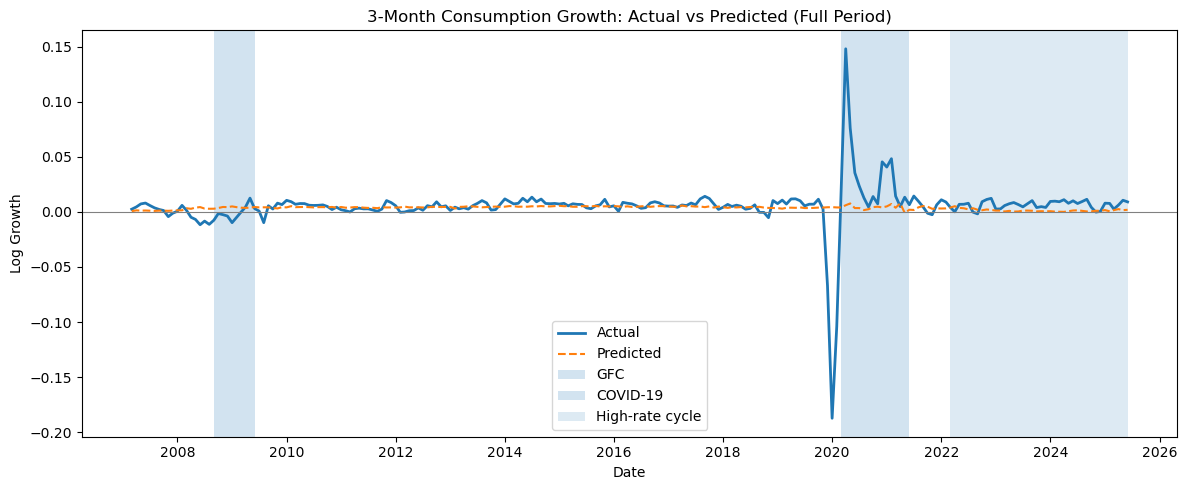

In [15]:
"""
Outlier during COVID-19 period significantly degrades the model performance
"""

# Full period prediction
X_full = model_df[features]

X_full_s = scaler.transform(X_full)  
pred_full = model.predict(X_full_s)

plt.figure(figsize=(12,5))
plt.plot(model_df["DATE"], model_df["3m_PCE_change"], label="Actual", linewidth=2)
plt.plot(model_df["DATE"], pred_full, label="Predicted", linestyle="--")

# Key periods
plt.axvspan("2008-09-01", "2009-06-01", alpha=0.2, label="GFC")
plt.axvspan("2020-03-01", "2021-06-01", alpha=0.2, label="COVID-19")
plt.axvspan("2022-03-01", model_df["DATE"].max(), alpha=0.15, label="High-rate cycle")

plt.axhline(0, color="gray", linewidth=0.8)
plt.legend()
plt.title("3-Month Consumption Growth: Actual vs Predicted (Full Period)")
plt.xlabel("Date")
plt.ylabel("Log Growth")
plt.tight_layout()
plt.show()


In [23]:

COVID_START = pd.Timestamp("2019-12-01")
COVID_END   = pd.Timestamp("2021-06-01")

covid_mask = (
    (test_df["DATE"] >= COVID_START) & (test_df["DATE"] <= COVID_END)
)

X_test_no_covid_scaled = X_test_scaled[~covid_mask]
y_test_no_covid        = y_test[~covid_mask]

print("Test rows (with COVID):", len(y_test))
print("Test rows (no COVID):", len(y_test_no_covid))

Test rows (with COVID): 66
Test rows (no COVID): 48


In [24]:
for a in [0.1, 1.0, 5.0, 10.0]:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)

    pred_all = model.predict(X_test_scaled)
    rmse_all = np.sqrt(mean_squared_error(y_test, pred_all))
    r2_all   = r2_score(y_test, pred_all)

    pred_no_covid = model.predict(X_test_no_covid_scaled)
    rmse_no_covid = np.sqrt(mean_squared_error(y_test_no_covid, pred_no_covid))
    r2_no_covid   = r2_score(y_test_no_covid, pred_no_covid)

    print(
        f"alpha={a}, "
        f"WITH_COVID RMSE={rmse_all:.4f}, R2={r2_all:.4f} | "
        f"NO_COVID RMSE={rmse_no_covid:.4f}, R2={r2_no_covid:.4f}"
    )

alpha=0.1, WITH_COVID RMSE=0.0353, R2=-0.0144 | NO_COVID RMSE=0.0068, R2=-1.8865
alpha=1.0, WITH_COVID RMSE=0.0353, R2=-0.0142 | NO_COVID RMSE=0.0068, R2=-1.8667
alpha=5.0, WITH_COVID RMSE=0.0353, R2=-0.0133 | NO_COVID RMSE=0.0067, R2=-1.7863
alpha=10.0, WITH_COVID RMSE=0.0353, R2=-0.0124 | NO_COVID RMSE=0.0066, R2=-1.6999


In [ ]:
print("Test date range:",
      test_df["DATE"].min(), "to", test_df["DATE"].max())

print("COVID rows in test:",
      ((test_df["DATE"] >= "2020-03-01") &
       (test_df["DATE"] <= "2021-06-01")).sum())

print("Test rows (with COVID):", len(y_test))
print("Test rows (no COVID):", len(y_test_no_covid))
print("Removed rows:", len(y_test) - len(y_test_no_covid))

excluded_dates = test_df.loc[covid_mask, "DATE"]
print(excluded_dates.head())
print(excluded_dates.tail())

Test date range: 2020-01-01 00:00:00 to 2025-06-01 00:00:00
COVID rows in test: 16
Test rows (with COVID): 66
Test rows (no COVID): 48
Removed rows: 18
154   2020-01-01
155   2020-02-01
156   2020-03-01
157   2020-04-01
158   2020-05-01
Name: DATE, dtype: datetime64[ns]
167   2021-02-01
168   2021-03-01
169   2021-04-01
170   2021-05-01
171   2021-06-01
Name: DATE, dtype: datetime64[ns]


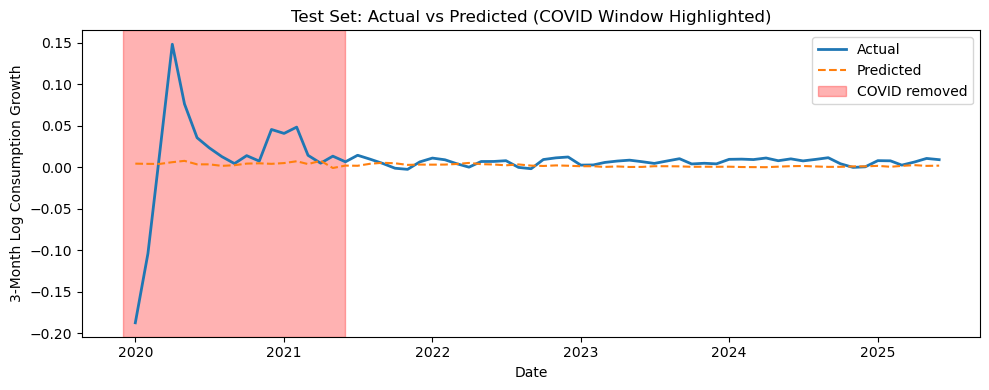

In [ ]:
plt.figure(figsize=(10,4))

# Actual
plt.plot(test_df["DATE"], y_test, label="Actual", linewidth=2)

# Predicted
pred_test = model.predict(X_test_scaled) 
plt.plot(test_df["DATE"], pred_test, label="Predicted", linestyle="--")

# COVID window
plt.axvspan("2019-12-01", "2021-06-01",
            alpha=0.3, color="red", label="COVID removed")

plt.legend()
plt.title("Test Set: Actual vs Predicted (COVID Window Highlighted)")
plt.xlabel("Date")
plt.ylabel("3-Month Log Consumption Growth")
plt.tight_layout()
plt.show()


In [28]:
coef = pd.Series(model.coef_, index=features).sort_values()
print(coef)

FEDFUNDS_lag1      -0.001163
UNRATE_lag1        -0.000625
CORE_CPI_d1_lag1   -0.000382
COVID               0.000000
CPI_d1_lag1         0.000110
DSPIC96_d1_lag1     0.000124
dtype: float64
